# 01 — Препроцессинг Yelp в гетерогенный граф

Строим граф с отношениями `review / tip / friend / in_category / located_in`,
временной сплит для review/tip, hold-out для friend (candidate generation).

Перед запуском: в `configs/base.yaml` указать `data_dir` на папку с Yelp JSON.

In [1]:
import os
from pathlib import Path

# фикс рабочей директории: ноутбук в notebooks/, а модуль src/ в корне проекта
if Path.cwd().name == "notebooks":
    os.chdir("..")
print("cwd:", Path.cwd())
assert (Path.cwd() / "src").is_dir(), "запускай из корня проекта (где лежит src/)"

cwd: /home/nikita/DL/recsys/twhin_yelp_3


In [2]:
!python -m src.data.preprocess --config configs/base.yaml

Loading businesses...
Businesses in PA: 34039
Loading reviews...
Reviews: 1,598,960
Loading tips...
Tips: 193,609
Loading users + friends...
Users loaded: 434,914
Friend edges: 1,271,665
Entity counts
  users:      434,918
  businesses: 34,039
  categories: 1,158
  cities:     434
  total:      470,549
Saved graph to: outputs/yelp_graph


## Отчёт о сплите

In [3]:
import json
import yaml

cfg = yaml.safe_load(open("configs/base.yaml"))
out_dir = Path(cfg["out_dir"])
report = json.load(open(out_dir / "split_report.json"))
report

{'dataset': 'Yelp Open Dataset',
 'state': 'PA',
 'entities': {'users': 434918,
  'businesses': 34039,
  'categories': 1158,
  'cities': 434,
  'total': 470549},
 'relations': {'review': 0,
  'tip': 1,
  'friend': 2,
  'in_category': 3,
  'located_in': 4},
 'splits': {'train_end': '2020-12-31',
  'val_end': '2021-06-30',
  'test_after': '2021-06-30'},
 'edges': {'review_train': 1490530,
  'review_val': 48934,
  'review_test': 59496,
  'tip_train': 187331,
  'tip_val': 3083,
  'tip_test': 3195,
  'friend_train': 1144499,
  'friend_test': 122860,
  'in_category_train': 128661,
  'located_in_train': 34039},
 'total_train_edges': 2985060}

## Проверки графа

Что граф построился корректно: файлы на месте, ID в диапазоне словаря,
friend_test создан и без утечки, ablation-папки согласованы.

In [4]:
import pandas as pd
import pyarrow.parquet as pq

entities = pq.read_table(out_dir / "entities.parquet").to_pandas()
relations = pq.read_table(out_dir / "relations.parquet").to_pandas()
n_ent = len(entities)
print("сущностей:", n_ent)
print(entities["entity_type"].value_counts().to_dict())
print("отношения:", dict(zip(relations["name"], relations["relation_id"])))

# 1) ID не выходят за словарь
def check_ids(path):
    df = pd.read_csv(path, sep="\t", header=None, names=["s", "r", "d"])
    assert df["s"].max() < n_ent and df["d"].max() < n_ent, f"{path}: ID вне словаря"
    assert df["s"].min() >= 0 and df["d"].min() >= 0, f"{path}: отрицательный ID"
    return len(df)

for name in ["train.tsv", "val.tsv", "test.tsv", "friend_train.tsv"]:
    print(f"{name}: {check_ids(out_dir / name):,} рёбер — ID ок")

сущностей: 470549
{'user': 434918, 'business': 34039, 'category': 1158, 'city': 434}
отношения: {'review': 0, 'tip': 1, 'friend': 2, 'in_category': 3, 'located_in': 4}
train.tsv: 2,985,060 рёбер — ID ок
val.tsv: 52,017 рёбер — ID ок
test.tsv: 62,691 рёбер — ID ок
friend_train.tsv: 1,144,499 рёбер — ID ок


In [5]:
# 2) friend_test создан и не пересекается с friend_train (leak-free)
ft = out_dir / "friend_test.tsv"
assert ft.exists(), "friend_test.tsv не создан — retrieval не заработает!"

tr = pd.read_csv(out_dir / "friend_train.tsv", sep="\t", header=None, names=["s", "r", "d"])
te = pd.read_csv(ft, sep="\t", header=None, names=["s", "r", "d"])

train_pairs = set(map(frozenset, zip(tr.s, tr.d)))
test_pairs = set(map(frozenset, zip(te.s, te.d)))
assert not (train_pairs & test_pairs), "friend_test пересекается с friend_train!"

train_users = set(tr.s) | set(tr.d)
cold = te[~(te.s.isin(train_users) & te.d.isin(train_users))]
assert len(cold) == 0, f"в friend_test {len(cold)} рёбер с cold-сущностями"
print(f"friend: train={len(tr):,}  test={len(te):,}  — leak-free ок")

friend: train=1,144,499  test=122,860  — leak-free ок


In [6]:
# 3) ablation-папки: train отличается, val/test одинаковы
ablations = ["all", "review_only", "no_tip", "no_friend", "review_friend"]
rows = []
for ab in ablations:
    p = out_dir / f"ablation_{ab}" / "train.tsv"
    if p.exists():
        df = pd.read_csv(p, sep="\t", header=None, names=["s", "r", "d"])
        rels = df["r"].value_counts().to_dict()
        rows.append({"ablation": ab, "edges": len(df), "relations": sorted(rels.keys())})
pd.DataFrame(rows)

,ablation,edges,relations
0,all,2985060,"[0, 1, 2, 3, 4]"
1,review_only,1490530,[0]
2,no_tip,2797729,"[0, 2, 3, 4]"
3,no_friend,1840561,"[0, 1, 3, 4]"
4,review_friend,2797729,"[0, 2, 3, 4]"


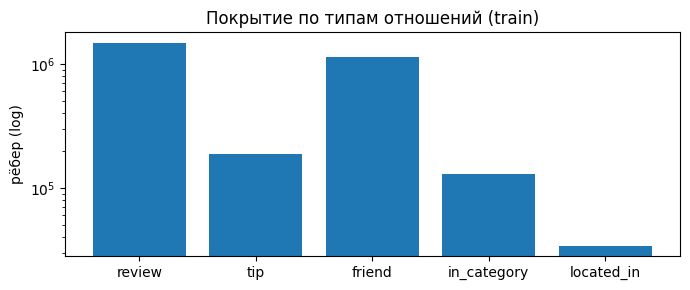

  review        : 1,490,530
  tip           :   187,331
  friend        : 1,144,499
  in_category   :   128,661
  located_in    :    34,039


In [7]:
# 4) распределение рёбер по типам отношений — high vs low coverage
import matplotlib.pyplot as plt

tr_all = pd.read_csv(out_dir / "train.tsv", sep="\t", header=None, names=["s", "r", "d"])
rel_name = dict(zip(relations["relation_id"], relations["name"]))
counts = tr_all["r"].value_counts().sort_index()
names = [rel_name[i] for i in counts.index]

plt.figure(figsize=(7, 3))
plt.bar(names, counts.values)
plt.yscale("log")
plt.ylabel("рёбер (log)")
plt.title("Покрытие по типам отношений (train)")
plt.tight_layout(); plt.show()

for n, c in zip(names, counts.values):
    print(f"  {n:14s}: {c:>9,}")